### Рализованы WGAN с weight clipping и WGAN с Gradient Penalty

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import torchvision
import matplotlib.pyplot as plt
import numpy as np
import os

from torch.autograd import Variable
from torch.autograd import grad

class Config:
    pass

config = Config()
config.mnist_path = None
config.batch_size = 64
config.num_workers = 3
config.num_epochs = 10
config.noise_size = 100
config.print_freq = 100
config.clip_value = 0.003  #Значение для weight clipping
config.lambda_gp = 10  #Коэффициент для gradient penalty
config.n_critic = 7  #Количество итераций критика на одну итерацию генератора
config.num_classes = 10  #10 классов для FashionMNIST

#директории для сохранения результатов
os.makedirs('wgan_clipping_results', exist_ok=True)
os.makedirs('wgan_gp_results', exist_ok=True)

In [ ]:

train = torchvision.datasets.FashionMNIST("fashion_mnist", train=True, transform=torchvision.transforms.ToTensor(), download=True)
dataloader = DataLoader(train, batch_size=config.batch_size, shuffle=True)

# Классификация FashionMNIST
fashion_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#Общие модели условной генерации

class ConditionalGenerator(nn.Module):
    def __init__(self):
        super(ConditionalGenerator, self).__init__()
        self.label_embedding = nn.Embedding(config.num_classes, 50)

        self.model = nn.Sequential(
            nn.Linear(config.noise_size + 50, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 28*28),
            nn.Tanh())

    def forward(self, z, labels):
        label_emb = self.label_embedding(labels)
        x = torch.cat([z, label_emb], dim=1)
        return self.model(x)

class ConditionalDiscriminator(nn.Module):
    def __init__(self):
        super(ConditionalDiscriminator, self).__init__()
        self.label_embedding = nn.Embedding(config.num_classes, 50)

        self.model = nn.Sequential(
            nn.Linear(28*28 + 50, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1))

    def forward(self, x, labels):
        label_emb = self.label_embedding(labels)
        x = torch.cat([x, label_emb], dim=1)
        return self.model(x)


In [ ]:
def weights_init(m):
    """Инициализация весов"""
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    elif classname.find('Embedding') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

In [ ]:
# WGAN с Weight Clipping

class WGAN_Clipping:
    def __init__(self):
        self.name = "WGAN_Clipping"
        self.generator = ConditionalGenerator()
        self.discriminator = ConditionalDiscriminator()

        self.generator.apply(weights_init)
        self.discriminator.apply(weights_init)

        # Оптимизаторы (RMSprop как в оригинальной статье WGAN)
        self.optim_G = optim.RMSprop(self.generator.parameters(), lr=0.0001)
        self.optim_D = optim.RMSprop(self.discriminator.parameters(), lr=0.0001)

        # История потерь
        self.D_losses = []
        self.G_losses = []
        self.wasserstein_distances = []

        #print(f"Инициализирован {self.name}")

    def clip_weights(self):
        for param in self.discriminator.parameters():
            param.data.clamp_(-config.clip_value, config.clip_value)

    def train_st(self, real_imgs, labels):
        batch_size = real_imgs.size(0)

        for i in range(config.n_critic):
            self.discriminator.zero_grad()
            z = torch.randn(batch_size, config.noise_size) #Шум для генератора
            fake_imgs = self.generator(z, labels)#Генерация изображений

            real_validity = self.discriminator(real_imgs, labels) #Реальные оценки

            fake_validity = self.discriminator(fake_imgs.detach(), labels) # Фейковые оценки

            d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) #Wasserstein loss для дискриминатора

            d_loss.backward()
            self.optim_D.step()
            self.clip_weights()


        self.generator.zero_grad()

        z = torch.randn(batch_size, config.noise_size) #Генерация новых изображений
        gen_imgs = self.generator(z, labels)
        fake_validity = self.discriminator(gen_imgs, labels)

        g_loss = -torch.mean(fake_validity)  #Потери генератора

        g_loss.backward()
        self.optim_G.step()

        self.D_losses.append(d_loss.item())
        self.G_losses.append(g_loss.item())

        # Вычисление Wasserstein distance
        with torch.no_grad():
            real_mean = torch.mean(real_validity).item()
            fake_mean = torch.mean(fake_validity).item()
            wasserstein_dist = real_mean - fake_mean
            self.wasserstein_distances.append(wasserstein_dist)

        return d_loss.item(), g_loss.item(), wasserstein_dist

    def generate_images(self, noise, labels):
        #Генерация изображений
        with torch.no_grad():
            return self.generator(noise, labels)

In [ ]:
#WGAN с Gradient Penalty

class WGAN_GP:
    def __init__(self):
        self.name = "WGAN_GP"

        self.generator = ConditionalGenerator()
        self.discriminator = ConditionalDiscriminator()

        self.generator.apply(weights_init)
        self.discriminator.apply(weights_init)
        #Оптимизаторы (Adam как в статье WGAN-GP)
        self.optim_G = optim.Adam(self.generator.parameters(), lr=0.0002, betas=(0.5, 0.9))
        self.optim_D = optim.Adam(self.discriminator.parameters(), lr=0.0002, betas=(0.5, 0.9))

        #История потерь
        self.D_losses = []
        self.G_losses = []


    def compute_gr_penalty(self, real_samples, fake_samples, labels):
        """Вычисляет gradient penalty для WGAN-GP"""
        alpha = torch.rand(real_samples.size(0), 1, device=real_samples.device)
        alpha = alpha.expand(real_samples.size())


        interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True) # Интерполяция между реальными и сгенерированными изображениями

        d_interpolates = self.discriminator(interpolates, labels) # оценка дискриминатора для интерполированных изображений

        # градиенты
        fake = torch.ones(real_samples.size(0), 1, device=real_samples.device)
        gradients = grad(outputs=d_interpolates, inputs=interpolates, grad_outputs=fake, create_graph=True, retain_graph=True, only_inputs=True)[0]

        # Вычисление gradient penalty
        gradients = gradients.view(gradients.size(0), -1)
        gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

        return gradient_penalty

    def train_st(self, real_imgs, labels):
        batch_size = real_imgs.size(0)
        for i in range(config.n_critic):
            self.discriminator.zero_grad()


            z = torch.randn(batch_size, config.noise_size)# Шум
            fake_imgs = self.generator(z, labels)
            real_validity = self.discriminator(real_imgs, labels)

            fake_validity = self.discriminator(fake_imgs.detach(), labels)


            gr_penalty = self.compute_gr_penalty(real_imgs.data, fake_imgs.data, labels) # Gradient penalty

            d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + config.lambda_gp * gr_penalty

            d_loss.backward()
            self.optim_D.step()


        self.generator.zero_grad()


        z = torch.randn(batch_size, config.noise_size)
        gen_imgs = self.generator(z, labels)
        fake_validity = self.discriminator(gen_imgs, labels)
        g_loss = -torch.mean(fake_validity)

        g_loss.backward()
        self.optim_G.step()

        self.D_losses.append(d_loss.item())
        self.G_losses.append(g_loss.item())

        return d_loss.item(), g_loss.item(), 0.0  #0 - для совместимости

    def generate_images(self, noise, labels):
        """Генерация изображений"""
        with torch.no_grad():
            return self.generator(noise, labels)


In [ ]:
#Обучение обеих моделей
wgan_clipping = WGAN_Clipping()
wgan_gp = WGAN_GP()


fixed_noise = torch.randn(16, config.noise_size) # Фиксированные данные для визуализации
fixed_labels = torch.randint(0, config.num_classes, (16,))

# Массивы для статистики
epoch_stats_clipping = []
epoch_stats_gp = []

for epoch in range(config.num_epochs):
    epoch_d_loss_clipping = 0
    epoch_g_loss_clipping = 0
    epoch_d_loss_gp = 0
    epoch_g_loss_gp = 0
    num_batches = 0

    for i, (real_imgs, labels) in enumerate(dataloader):
        batch_size = real_imgs.size(0)

        # Подготовка данных
        real_imgs = real_imgs.view(batch_size, -1)

        # Обучение WGAN с Weight Clipping
        d_loss_clip, g_loss_clip, w_dist = wgan_clipping.train_st(real_imgs, labels)
        epoch_d_loss_clipping += d_loss_clip
        epoch_g_loss_clipping += g_loss_clip

        # Обучение WGAN с Gradient Penalty
        d_loss_gp, g_loss_gp, _ = wgan_gp.train_st(real_imgs, labels)
        epoch_d_loss_gp += d_loss_gp
        epoch_g_loss_gp += g_loss_gp

        num_batches += 1

        # Вывод прогресса
        if i % config.print_freq == 0:
            print(f'Epoch [{epoch+1}/{config.num_epochs}] Batch [{i}/{len(dataloader)}]')
            print(f'  WGAN-Clipping: D_loss: {d_loss_clip:.4f} G_loss: {g_loss_clip:.4f} W_dist: {w_dist:.4f}')
            print(f'  WGAN-GP:       D_loss: {d_loss_gp:.4f} G_loss: {g_loss_gp:.4f}')
            print('-' * 60)

    # Средние потери за эпоху
    avg_d_clip = epoch_d_loss_clipping / num_batches
    avg_g_clip = epoch_g_loss_clipping / num_batches
    avg_d_gp = epoch_d_loss_gp / num_batches
    avg_g_gp = epoch_g_loss_gp / num_batches

    epoch_stats_clipping.append((avg_d_clip, avg_g_clip))
    epoch_stats_gp.append((avg_d_gp, avg_g_gp))

    print(f'\nЭпоха {epoch+1} завершена:')
    print(f'  WGAN-Clipping: Avg D_loss: {avg_d_clip:.4f} Avg G_loss: {avg_g_clip:.4f}')
    print(f'  WGAN-GP:       Avg D_loss: {avg_d_gp:.4f} Avg G_loss: {avg_g_gp:.4f}')

    # Сохранение изображений каждые 5 эпох
    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            # Генерация изображений обеими моделями
            fake_clip = wgan_clipping.generate_images(fixed_noise, fixed_labels)
            fake_gp = wgan_gp.generate_images(fixed_noise, fixed_labels)

            # Визуализация для WGAN-Clipping
            fig, axes = plt.subplots(2, 8, figsize=(16, 4))
            fig.suptitle(f'WGAN-Clipping - Epoch {epoch+1}', fontsize=16)

            for j in range(8):
                axes[0, j].imshow(fake_clip[j].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
                axes[0, j].set_title(fashion_classes[fixed_labels[j].item()], fontsize=8)
                axes[0, j].axis('off')

                axes[1, j].imshow(fake_clip[j+8].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
                axes[1, j].set_title(fashion_classes[fixed_labels[j+8].item()], fontsize=8)
                axes[1, j].axis('off')

            plt.tight_layout()
            plt.savefig(f'wgan_clipping_results/epoch_{epoch+1}.png')
            plt.close()

            # Визуализация для WGAN-GP
            fig, axes = plt.subplots(2, 8, figsize=(16, 4))
            fig.suptitle(f'WGAN-GP - Epoch {epoch+1}', fontsize=16)

            for j in range(8):
                axes[0, j].imshow(fake_gp[j].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
                axes[0, j].set_title(fashion_classes[fixed_labels[j].item()], fontsize=8)
                axes[0, j].axis('off')

                axes[1, j].imshow(fake_gp[j+8].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
                axes[1, j].set_title(fashion_classes[fixed_labels[j+8].item()], fontsize=8)
                axes[1, j].axis('off')

            plt.tight_layout()
            plt.savefig(f'wgan_gp_results/epoch_{epoch+1}.png')
            plt.close()

Epoch [1/10] Batch [0/938]
  WGAN-Clipping: D_loss: -0.0011 G_loss: 0.0002 W_dist: 0.0011
  WGAN-GP:       D_loss: 6.7244 G_loss: 0.0025
------------------------------------------------------------
Epoch [1/10] Batch [100/938]
  WGAN-Clipping: D_loss: -0.1342 G_loss: -0.0004 W_dist: 0.1270
  WGAN-GP:       D_loss: -6.3942 G_loss: -0.7726
------------------------------------------------------------
Epoch [1/10] Batch [200/938]
  WGAN-Clipping: D_loss: -0.1627 G_loss: 0.0151 W_dist: 0.1672
  WGAN-GP:       D_loss: -6.5658 G_loss: 0.1628
------------------------------------------------------------
Epoch [1/10] Batch [300/938]
  WGAN-Clipping: D_loss: -0.1559 G_loss: -0.0243 W_dist: 0.1619
  WGAN-GP:       D_loss: -6.0565 G_loss: -0.4725
------------------------------------------------------------
Epoch [1/10] Batch [400/938]
  WGAN-Clipping: D_loss: -0.1615 G_loss: 0.0555 W_dist: 0.1676
  WGAN-GP:       D_loss: -5.4069 G_loss: -1.1628
------------------------------------------------------

In [ ]:
# Статистика
print("\n" + "="*60)
print("СТАТИСТИКА ОБУЧЕНИЯ")
print("="*60)

print("WGAN-Clipping:")
print(f"Финальный D_loss: {epoch_stats_clipping[-1][0]:.4f}")
print(f"Финальный G_los: {epoch_stats_clipping[-1][1]:.4f}")
print(f"Среднее расстояние Вассерштейна: {np.mean(wgan_clipping.wasserstein_distances[-100:]):.4f}")
print(f"Стабильность обучения: {'Высокая' if np.std(wgan_clipping.D_losses[-100:]) < 0.35 else 'Средняя'}")

print("WGAN-GP:")
print(f"Финальный D_loss: {epoch_stats_gp[-1][0]:.4f}")
print(f"Финальный G_loss: {epoch_stats_gp[-1][1]:.4f}")
print(f"Стабильность обучения: {'Высокая' if np.std(wgan_gp.D_losses[-100:]) < 0.35 else 'Средняя'}")


СТАТИСТИКА ОБУЧЕНИЯ
WGAN-Clipping:
Финальный D_loss: -0.0050
Финальный G_los: 0.0018
Среднее расстояние Вассерштейна: 0.0064
Стабильность обучения: Высокая
WGAN-GP:
Финальный D_loss: -1.6931
Финальный G_loss: 4.5714
Стабильность обучения: Высокая



Сравнительный анализ WGAN-CLIPPING и WGAN-GP


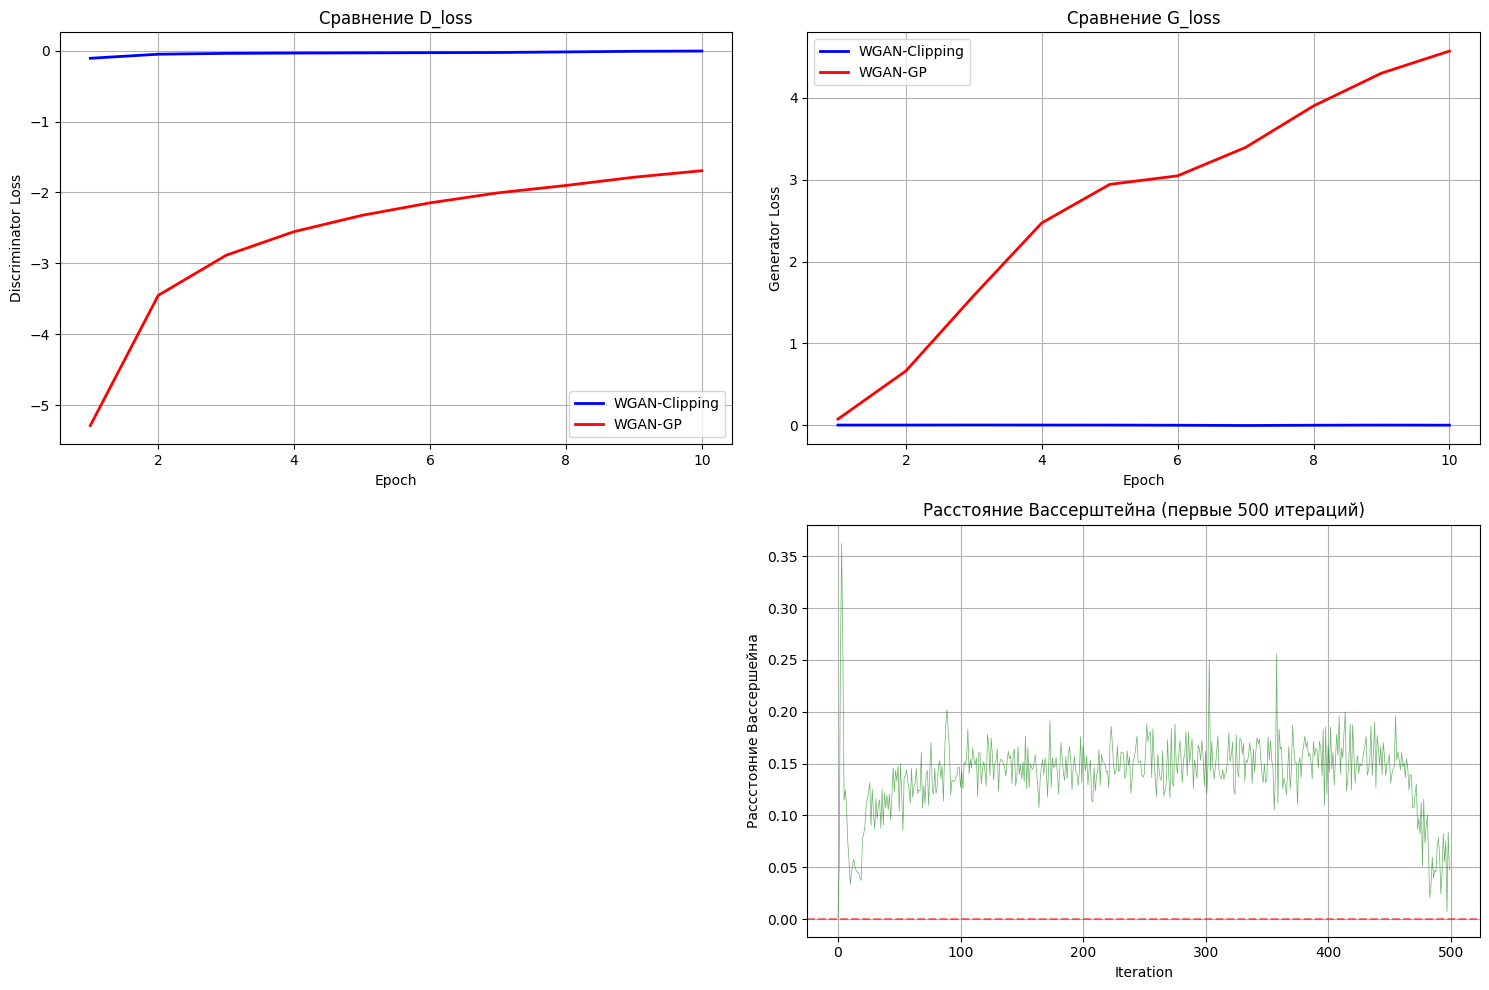

In [ ]:
print("\n" + "="*60)
print("Сравнительный анализ WGAN-CLIPPING и WGAN-GP")
print("="*60)

# 1. Графики потерь по эпохам
plt.figure(figsize=(15, 10))

# D_loss
plt.subplot(2, 2, 1)
epochs_range = range(1, config.num_epochs + 1)
d_clip_epochs = [stat[0] for stat in epoch_stats_clipping]
d_gp_epochs = [stat[0] for stat in epoch_stats_gp]
plt.plot(epochs_range, d_clip_epochs, 'b-', label='WGAN-Clipping', linewidth=2)
plt.plot(epochs_range, d_gp_epochs, 'r-', label='WGAN-GP', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Discriminator Loss')
plt.title('Сравнение D_loss')
plt.legend()
plt.grid(True)

# G_loss
plt.subplot(2, 2, 2)
g_clip_epochs = [stat[1] for stat in epoch_stats_clipping]
g_gp_epochs = [stat[1] for stat in epoch_stats_gp]
plt.plot(epochs_range, g_clip_epochs, 'b-', label='WGAN-Clipping', linewidth=2)
plt.plot(epochs_range, g_gp_epochs, 'r-', label='WGAN-GP', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Generator Loss')
plt.title('Сравнение G_loss')
plt.legend()
plt.grid(True)

# расстояние Вассерштейна
plt.subplot(2, 2, 4)
plt.plot(wgan_clipping.wasserstein_distances[:500], 'g-', alpha=0.6, linewidth=0.5)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Iteration')
plt.ylabel('Рассстояние Вассершейна')
plt.title('Расстояние Вассерштейна (первые 500 итераций)')
plt.grid(True)

plt.tight_layout()
plt.savefig('comparison_losses.png')
plt.show()

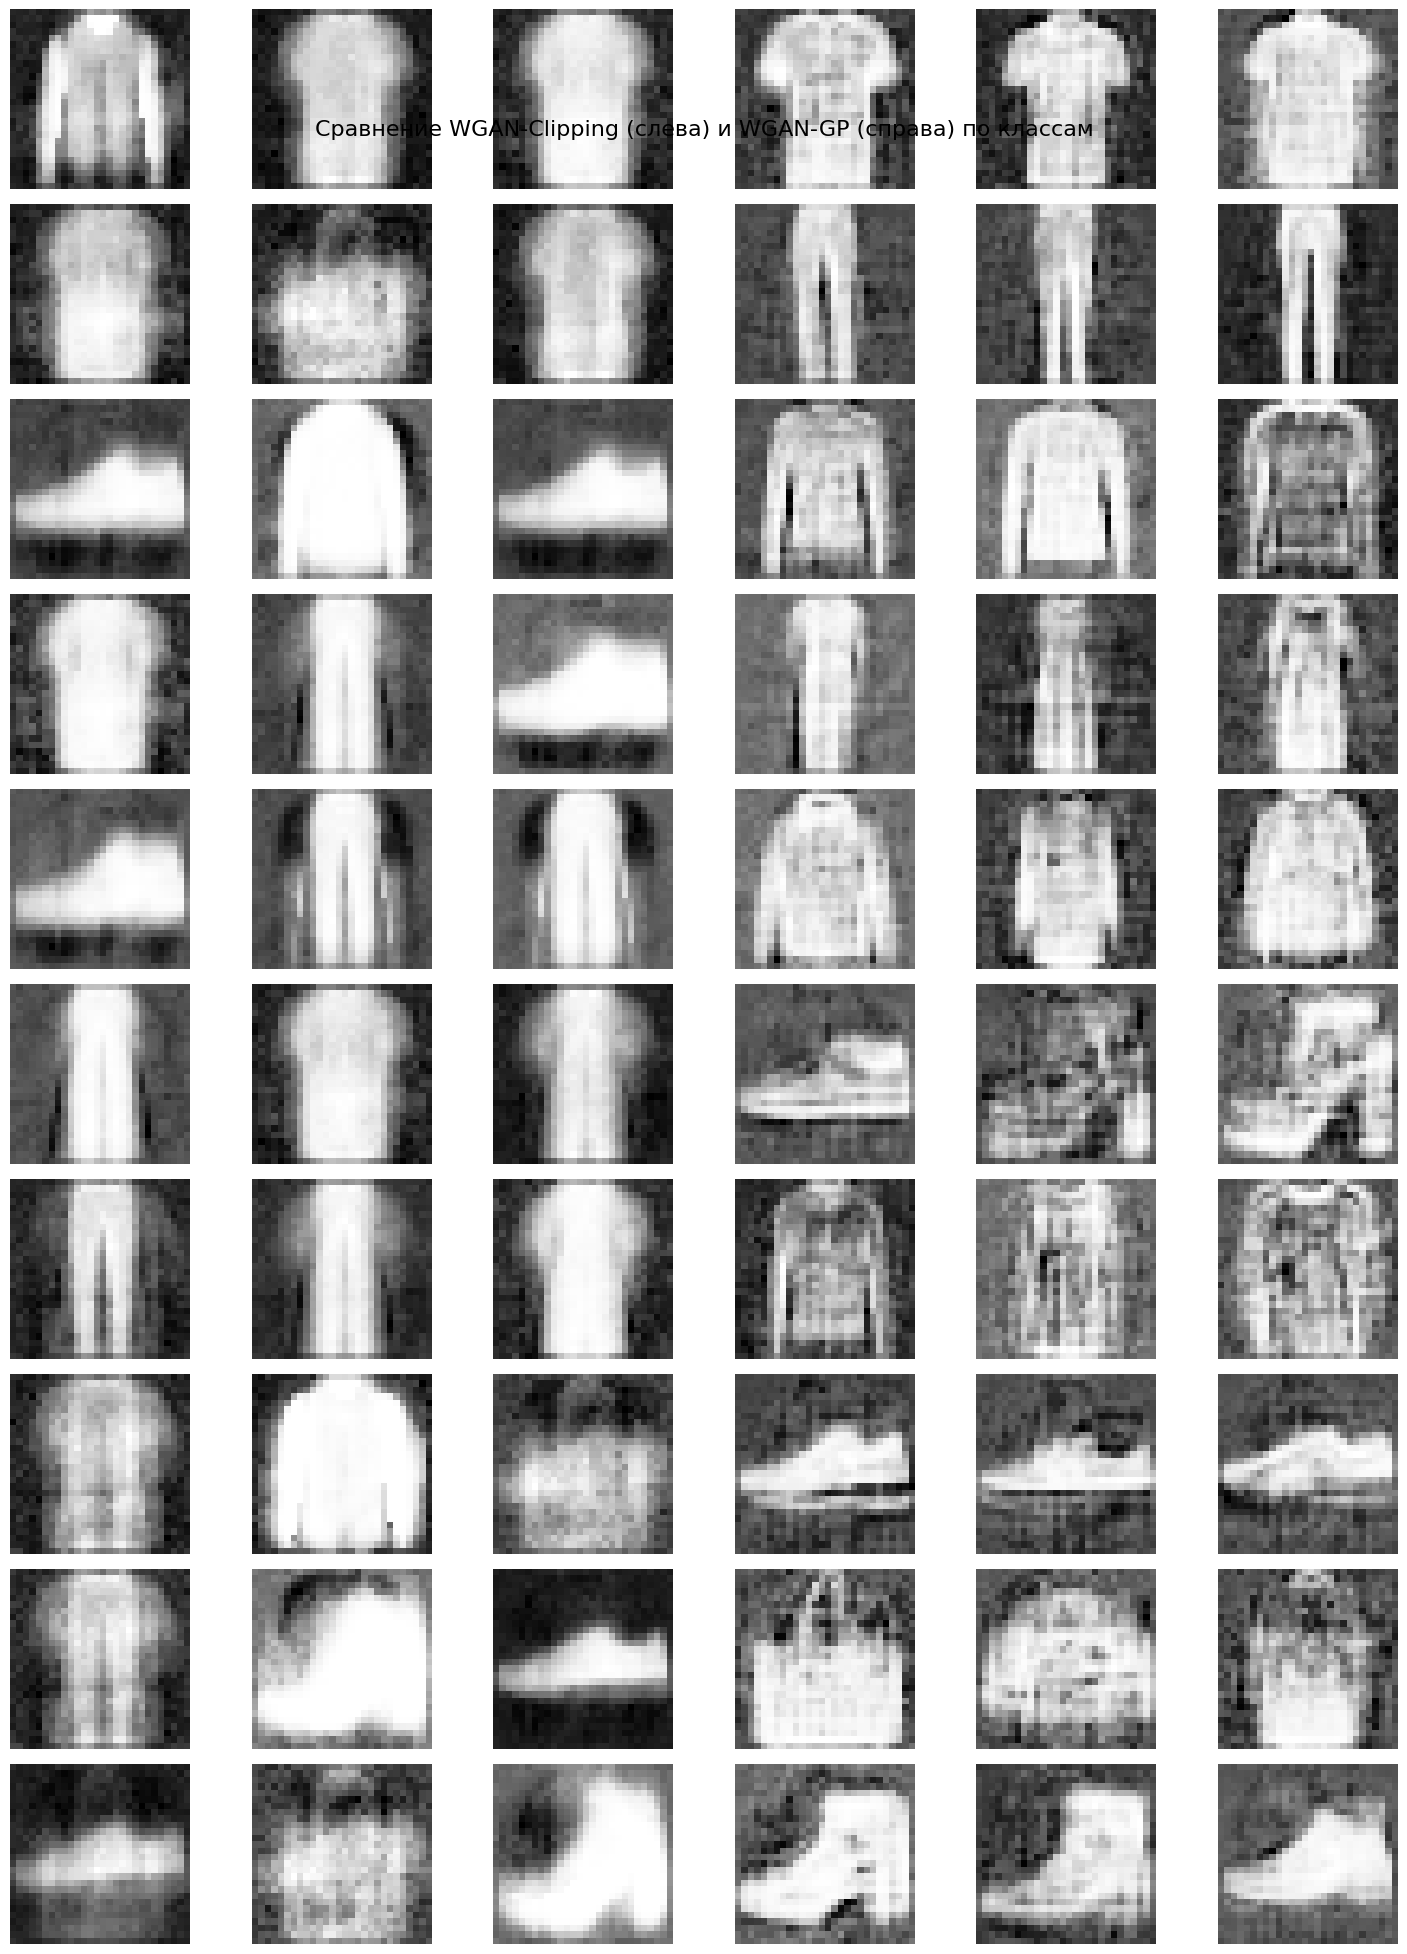

In [ ]:
#Финальная генерация для сравнения

# Генерация по всем классам
n_classes = config.num_classes
n_samples = 3

fig = plt.figure(figsize=(15, 20))

for class_idx in range(n_classes):
    # шум для текущего класса
    z = torch.randn(n_samples * 2, config.noise_size)
    labels = torch.full((n_samples * 2,), class_idx, dtype=torch.long)

    # Генерация обеими моделями
    with torch.no_grad():
        generated_clip = wgan_clipping.generate_images(z[:n_samples], labels[:n_samples])
        generated_gp = wgan_gp.generate_images(z[n_samples:], labels[n_samples:])

    # WGAN-Clipping
    for sample_idx in range(n_samples):
        ax = plt.subplot(n_classes, n_samples * 2, class_idx * (n_samples * 2) + sample_idx + 1)
        ax.imshow(generated_clip[sample_idx].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
        ax.axis('off')
        if sample_idx == 0:
            ax.set_ylabel(f'{fashion_classes[class_idx]}\nClipping', fontsize=10, rotation=0, ha='right', va='center')

    # WGAN-GP
    for sample_idx in range(n_samples):
        ax = plt.subplot(n_classes, n_samples * 2, class_idx * (n_samples * 2) + sample_idx + n_samples + 1)
        ax.imshow(generated_gp[sample_idx].detach().numpy().reshape(28, 28), cmap=plt.cm.Greys_r)
        ax.axis('off')
        if sample_idx == 0:
            ax.set_ylabel(f'{fashion_classes[class_idx]}\nGP', fontsize=10, rotation=0, ha='right', va='center')

plt.suptitle('Сравнение WGAN-Clipping (слева) и WGAN-GP (справа) по классам', fontsize=16, y=0.92)
plt.tight_layout()
plt.savefig('final_comparison_by_class.png')
plt.show()


Как видно из генераций в сравнении и в сохранённых во время обучения файлах, у WGUN_GP более чёткие изображения при генерации и меньше ошибок в определении классов (возмоно, плохая чёткость изображения у WGUN_Clipping обусловлена низким значением ограничителя clip_value, что, возможно привело к маленьким весам и затуханию градиентов при обучении сети данного типа и сеть недообучилась).